# Named Entity Recognition (NER) Model Comparison: Custom BioBERT-CRF vs. Deep Learning & Rule-Based Baselines

This notebook performs a rigorous scientific evaluation comparing our single unified **BioBERT-CRF** NER model (with CRF Viterbi decoding) against several distinct baselines, ablations, and individual expert models:
1. **BioBERT Linear (No CRF)**: Argmax decoding directly on the logits of our model, to measure the exact effect of the CRF transition layer.
2. **SOTA Specialized Deep Learning Models (Individual Experts)**:
   - **DISEASE Expert**: `alvaroalon2/biobert_diseases_ner` (trained exclusively for disease extraction)
   - **FOOD Expert**: `Dizex/FoodBaseBERT-NER` (trained exclusively for food extraction)
   - **NUTRIENT Expert**: `sgarbi/bert-fda-nutrition-ner` (trained exclusively for nutrient extraction)
3. **Merged SOTA Ensemble**: The combination of the predictions from all three individual specialized experts.
4. **spaCy PhraseMatcher Baseline**: A dictionary-based exact matching baseline using spaCy `PhraseMatcher` and tokenization.

All models are evaluated on the same 10% test split of our combined dataset (**BC5CDR** + **FoodBase**), consisting of **1,723 sentences** containing **3,846 gold entities**. The metric used is strict entity-level span matching (`seqeval`).

## 1. Methodology & Alignment

### Baseline Models and Mappings
- **DISEASE Class**: Compared against `alvaroalon2/biobert_diseases_ner`. Any predicted tag with `DISEASE` is kept, others are set to `O`.
- **FOOD Class**: Compared against `Dizex/FoodBaseBERT-NER`. Any predicted tag with `FOOD` is kept, others are set to `O`.
- **NUTRIENT Class**: Compared against `sgarbi/bert-fda-nutrition-ner`. Since it identifies specific food components (e.g. `VITAMINS`, `PROTEIN`, `CARBOHYDRATES`), any non-`O` prediction is mapped directly to `NUTRIENT`.

### Ensemble Baseline Construction
To compute an **Overall F1-score** for the specialized models, we merge the token-level predictions of all three baseline models for each sentence (preferring predictions in the order of Disease $\rightarrow$ Food $\rightarrow$ Nutrient, though conflicts are rare due to disjoint vocabularies) and compare the merged predictions against the unified ground truth.

### Section 1.1: Library Imports & Env Config
On Windows, we configure environment variables before initializing CUDA context to prevent OpenMP DLL load issues.

In [10]:
# Cell 1.1: Environment configuration
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json
import sys
import numpy as np
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification

# Set path relative to notebooks directory
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

sns.set_theme(style="whitegrid")
print("All basic libraries imported successfully.")

All basic libraries imported successfully.


In [11]:
# Cell 1.2: Import PyTorch & project model
import torch
from src.en.ner import BertCRFForTokenClassification
print("PyTorch and project models imported successfully.")

PyTorch and project models imported successfully.


In [12]:
# Cell 1.3: Hardware verification (CUDA Initialization)
print("PyTorch version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("Running on CPU.")
    device = torch.device("cpu")

PyTorch version: 2.6.0+cu124
CUDA Available: True
GPU Device: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Load Evaluation Data

We load the test split of the combined dataset. We ensure reproducibility by seeding the shuffle operation exactly as done in training.

In [13]:
# Cell 2: Load evaluation data
custom_model_path = "../../models/ner_bert"
bc5cdr_path = "../../data/en/bc5cdr_bio.jsonl"
food_path = "../../data/en/food_bio.jsonl"

LABEL_LIST = ["O", "B-NUTRIENT", "I-NUTRIENT", "B-DISEASE", "I-DISEASE", "B-FOOD", "I-FOOD"]
label2id = {l: i for i, l in enumerate(LABEL_LIST)}
id2label = {i: l for l, i in label2id.items()}

# Load both datasets
rows = []
if os.path.exists(bc5cdr_path):
    with open(bc5cdr_path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
if os.path.exists(food_path):
    with open(food_path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))

# Seed and shuffle to extract the exact 10% test split
import random
random.seed(42)
random.shuffle(rows)

test_idx = int(len(rows) * 0.9)
test_rows = rows[test_idx:]

print(f"Total Combined Rows: {len(rows)}")
print(f"Test Split Size: {len(test_rows)} sentences")

Total Combined Rows: 17223
Test Split Size: 1723 sentences


## 3. Run Inference on GPU

In [14]:
# Cell 3.1: Evaluate our Custom BioBERT-CRF Model (Viterbi vs. Argmax)
custom_tokenizer = AutoTokenizer.from_pretrained(custom_model_path)
custom_model = BertCRFForTokenClassification.from_pretrained(custom_model_path)
custom_model.eval()
custom_model.to(device)

seqeval = evaluate.load("seqeval")
true_labels = []
custom_pred_labels = []
argmax_pred_labels = []

print(f"Running inference for Custom BioBERT (Viterbi and Argmax) on: {device}...")
for idx, row in enumerate(test_rows):
    tokens = row["tokens"]
    labels = row["labels"]
    
    inputs = custom_tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    
    model_inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = custom_model(**model_inputs)
        
    logits = outputs.logits
    mask = (model_inputs["attention_mask"] == 1)
    
    # 1. CRF Viterbi decoding
    decoded_paths = custom_model.crf.decode(logits, mask)
    path = decoded_paths[0]
    
    # 2. Standard Argmax decoding (No CRF)
    argmax_path = torch.argmax(logits, dim=-1)[0].tolist()
    
    word_ids = inputs.word_ids(batch_index=0)
    prev_word_id = None
    
    row_true = []
    row_pred = []
    row_argmax = []
    
    for i, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != prev_word_id:
            if word_id < len(labels):
                row_true.append(labels[word_id])
                row_pred.append(id2label[path[i]])
                row_argmax.append(id2label[argmax_path[i]])
        prev_word_id = word_id
        
    true_labels.append(row_true)
    custom_pred_labels.append(row_pred)
    argmax_pred_labels.append(row_argmax)

custom_results = seqeval.compute(predictions=custom_pred_labels, references=true_labels)
argmax_results = seqeval.compute(predictions=argmax_pred_labels, references=true_labels)
print("Custom models inference completed.")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4739.67it/s]


Running inference for Custom BioBERT (Viterbi and Argmax) on: cuda...
Custom models inference completed.


In [15]:
# Cell 3.2: Evaluate SOTA Specialized Baselines (Disease, Food, Nutrient models)
print("Loading specialized baseline models from HuggingFace...")
disease_tok = AutoTokenizer.from_pretrained("alvaroalon2/biobert_diseases_ner")
disease_mod = AutoModelForTokenClassification.from_pretrained("alvaroalon2/biobert_diseases_ner").to(device).eval()

food_tok = AutoTokenizer.from_pretrained("Dizex/FoodBaseBERT-NER")
food_mod = AutoModelForTokenClassification.from_pretrained("Dizex/FoodBaseBERT-NER").to(device).eval()

nut_tok = AutoTokenizer.from_pretrained("sgarbi/bert-fda-nutrition-ner")
nut_mod = AutoModelForTokenClassification.from_pretrained("sgarbi/bert-fda-nutrition-ner").to(device).eval()

dis_id2label = disease_mod.config.id2label
food_id2label = food_mod.config.id2label
nut_id2label = nut_mod.config.id2label

disease_preds_list = []
food_preds_list = []
nut_preds_list = []
baseline_merged_preds = []

print("Running inference for specialized baseline models...")
for idx, row in enumerate(test_rows):
    tokens = row["tokens"]
    labels = row["labels"]
    
    # 1. Disease inference
    inputs_dis = disease_tok(tokens, is_split_into_words=True, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        preds_dis = torch.argmax(disease_mod(**{k: v.to(device) for k, v in inputs_dis.items()}).logits, dim=-1)[0].tolist()
        
    # 2. Food inference
    inputs_food = food_tok(tokens, is_split_into_words=True, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        preds_food = torch.argmax(food_mod(**{k: v.to(device) for k, v in inputs_food.items()}).logits, dim=-1)[0].tolist()
        
    # 3. Nutrient inference
    inputs_nut = nut_tok(tokens, is_split_into_words=True, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        preds_nut = torch.argmax(nut_mod(**{k: v.to(device) for k, v in inputs_nut.items()}).logits, dim=-1)[0].tolist()
        
    # Word alignment helper, mapping both character 'O' and digit '0' to outside tag
    def align_predictions(w_ids, predictions, id2label, target_class):
        aligned = ["O"] * len(labels)
        prev_wid = None
        for i, wid in enumerate(w_ids):
            if wid is None or wid >= len(labels):
                continue
            if wid != prev_wid:
                raw_tag = id2label[predictions[i]]
                if raw_tag not in ["O", "0"]:
                    bio = raw_tag[0]
                    aligned[wid] = f"{bio}-{target_class}"
            prev_wid = wid
        return aligned
        
    aligned_dis = align_predictions(inputs_dis.word_ids(batch_index=0), preds_dis, dis_id2label, "DISEASE")
    aligned_food = align_predictions(inputs_food.word_ids(batch_index=0), preds_food, food_id2label, "FOOD")
    aligned_nut = align_predictions(inputs_nut.word_ids(batch_index=0), preds_nut, nut_id2label, "NUTRIENT")
    
    disease_preds_list.append(aligned_dis)
    food_preds_list.append(aligned_food)
    nut_preds_list.append(aligned_nut)
    
    # Merge predictions across three specialist models
    merged_row = []
    for d_p, f_p, n_p in zip(aligned_dis, aligned_food, aligned_nut):
        if d_p != "O":
            merged_row.append(d_p)
        elif f_p != "O":
            merged_row.append(f_p)
        elif n_p != "O":
            merged_row.append(n_p)
        else:
            merged_row.append("O")
    baseline_merged_preds.append(merged_row)

disease_results = seqeval.compute(predictions=disease_preds_list, references=true_labels)
food_results = seqeval.compute(predictions=food_preds_list, references=true_labels)
nut_results = seqeval.compute(predictions=nut_preds_list, references=true_labels)
baseline_results = seqeval.compute(predictions=baseline_merged_preds, references=true_labels)
print("Baseline models evaluation completed.")

Loading specialized baseline models from HuggingFace...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2335.63it/s]


Running inference for specialized baseline models...
Baseline models evaluation completed.


In [16]:
# Cell 3.3: Evaluate spaCy PhraseMatcher Baseline
import spacy
from spacy.matcher import PhraseMatcher
from src.en.ner import _FOOD_TOKENS, _DISEASE_TOKENS, _NUTRIENT_TOKENS

print("Loading spaCy model and compiling PhraseMatcher patterns...")
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "tagger", "attribute_ruler", "lemmatizer"])
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

food_patterns = list(nlp.pipe(list(_FOOD_TOKENS)))
disease_patterns = list(nlp.pipe(list(_DISEASE_TOKENS)))
nutrient_patterns = list(nlp.pipe(list(_NUTRIENT_TOKENS)))

matcher.add("FOOD", food_patterns)
matcher.add("DISEASE", disease_patterns)
matcher.add("NUTRIENT", nutrient_patterns)

spacy_pred_labels = []

print("Running inference for spaCy PhraseMatcher Baseline...")
for idx, row in enumerate(test_rows):
    tokens = row["tokens"]
    labels = row["labels"]
    
    text = " ".join(tokens)
    doc = nlp(text)
    
    token_offsets = []
    current_offset = 0
    for token in tokens:
        start = current_offset
        end = start + len(token)
        token_offsets.append((start, end))
        current_offset = end + 1
        
    row_pred = ["O"] * len(tokens)
    matches = matcher(doc)
    
    for match_id, start_idx, end_idx in matches:
        ent_type = nlp.vocab.strings[match_id]
        span = doc[start_idx:end_idx]
        span_start = span.start_char
        span_end = span.end_char
        
        is_first = True
        for i, (t_start, t_end) in enumerate(token_offsets):
            if max(t_start, span_start) < min(t_end, span_end):
                if is_first:
                    row_pred[i] = f"B-{ent_type}"
                    is_first = False
                else:
                    row_pred[i] = f"I-{ent_type}"
                    
    spacy_pred_labels.append(row_pred)

spacy_results = seqeval.compute(predictions=spacy_pred_labels, references=true_labels)
print("spaCy Baseline evaluation completed.")

Loading spaCy model and compiling PhraseMatcher patterns...
Running inference for spaCy PhraseMatcher Baseline...
spaCy Baseline evaluation completed.


## 4. Comparative Quantitative Report

In [17]:
# Cell 4.1: Comparative classification report
print("="*195)
print(f"{'Entity Class':<12} | {'Custom CRF':<20} | {'BioBERT Argmax':<20} | {'Disease Expert':<20} | {'Food Expert':<20} | {'Nutrient Expert':<20} | {'Merged SOTA':<20} | {'spaCy PM':<20} | {'Support':<8}")
print("="*195)
for entity in ['DISEASE', 'FOOD', 'NUTRIENT']:
    c_m = custom_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    a_m = argmax_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    d_m = disease_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    f_m = food_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    n_m = nut_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    b_m = baseline_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    s_m = spacy_results.get(entity, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 0})
    
    print(f"{entity:<12} | "
          f"{c_m['precision']:.4f}/{c_m['recall']:.4f}/{c_m['f1']:.4f} | "
          f"{a_m['precision']:.4f}/{a_m['recall']:.4f}/{a_m['f1']:.4f} | "
          f"{d_m['precision']:.4f}/{d_m['recall']:.4f}/{d_m['f1']:.4f} | "
          f"{f_m['precision']:.4f}/{f_m['recall']:.4f}/{f_m['f1']:.4f} | "
          f"{n_m['precision']:.4f}/{n_m['recall']:.4f}/{n_m['f1']:.4f} | "
          f"{b_m['precision']:.4f}/{b_m['recall']:.4f}/{b_m['f1']:.4f} | "
          f"{s_m['precision']:.4f}/{s_m['recall']:.4f}/{s_m['f1']:.4f} | "
          f"{c_m['number']:<8}")
print("-"*195)
print(f"{'Overall':<12} | "
      f"{custom_results['overall_precision']:.4f}/{custom_results['overall_recall']:.4f}/{custom_results['overall_f1']:.4f} | "
      f"{argmax_results['overall_precision']:.4f}/{argmax_results['overall_recall']:.4f}/{argmax_results['overall_f1']:.4f} | "
      f"{disease_results['overall_precision']:.4f}/{disease_results['overall_recall']:.4f}/{disease_results['overall_f1']:.4f} | "
      f"{food_results['overall_precision']:.4f}/{food_results['overall_recall']:.4f}/{food_results['overall_f1']:.4f} | "
      f"{nut_results['overall_precision']:.4f}/{nut_results['overall_recall']:.4f}/{nut_results['overall_f1']:.4f} | "
      f"{baseline_results['overall_precision']:.4f}/{baseline_results['overall_recall']:.4f}/{baseline_results['overall_f1']:.4f} | "
      f"{spacy_results['overall_precision']:.4f}/{spacy_results['overall_recall']:.4f}/{spacy_results['overall_f1']:.4f} |")
print("="*195)

Entity Class    | Custom CRF P/R/F1          | BioBERT Argmax P/R/F1      | Specialist P/R/F1          | spaCy P/R/F1               | Support 
DISEASE         | 0.9129/0.9284/0.9206 | 0.9137/0.9292/0.9214 | 0.9370/0.9507/0.9438 | 0.6667/0.0446/0.0837 | 1299    
FOOD            | 0.9838/0.9898/0.9868 | 0.9838/0.9898/0.9868 | 0.2567/0.9898/0.4076 | 0.4683/0.0979/0.1619 | 981     
NUTRIENT        | 0.9580/0.9770/0.9674 | 0.9586/0.9770/0.9677 | 0.0664/0.0492/0.0565 | 0.3188/0.0140/0.0269 | 1566    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Overall         | 0.9493/0.9639/0.9565 | 0.9498/0.9641/0.9569 | 0.3646/0.5936/0.4518 | 0.4875/0.0458/0.0837 |


## 5. Visualizing the Performance Comparison

C:\Users\dongb\AppData\Local\Temp\ipykernel_14100\3924242203.py:67: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


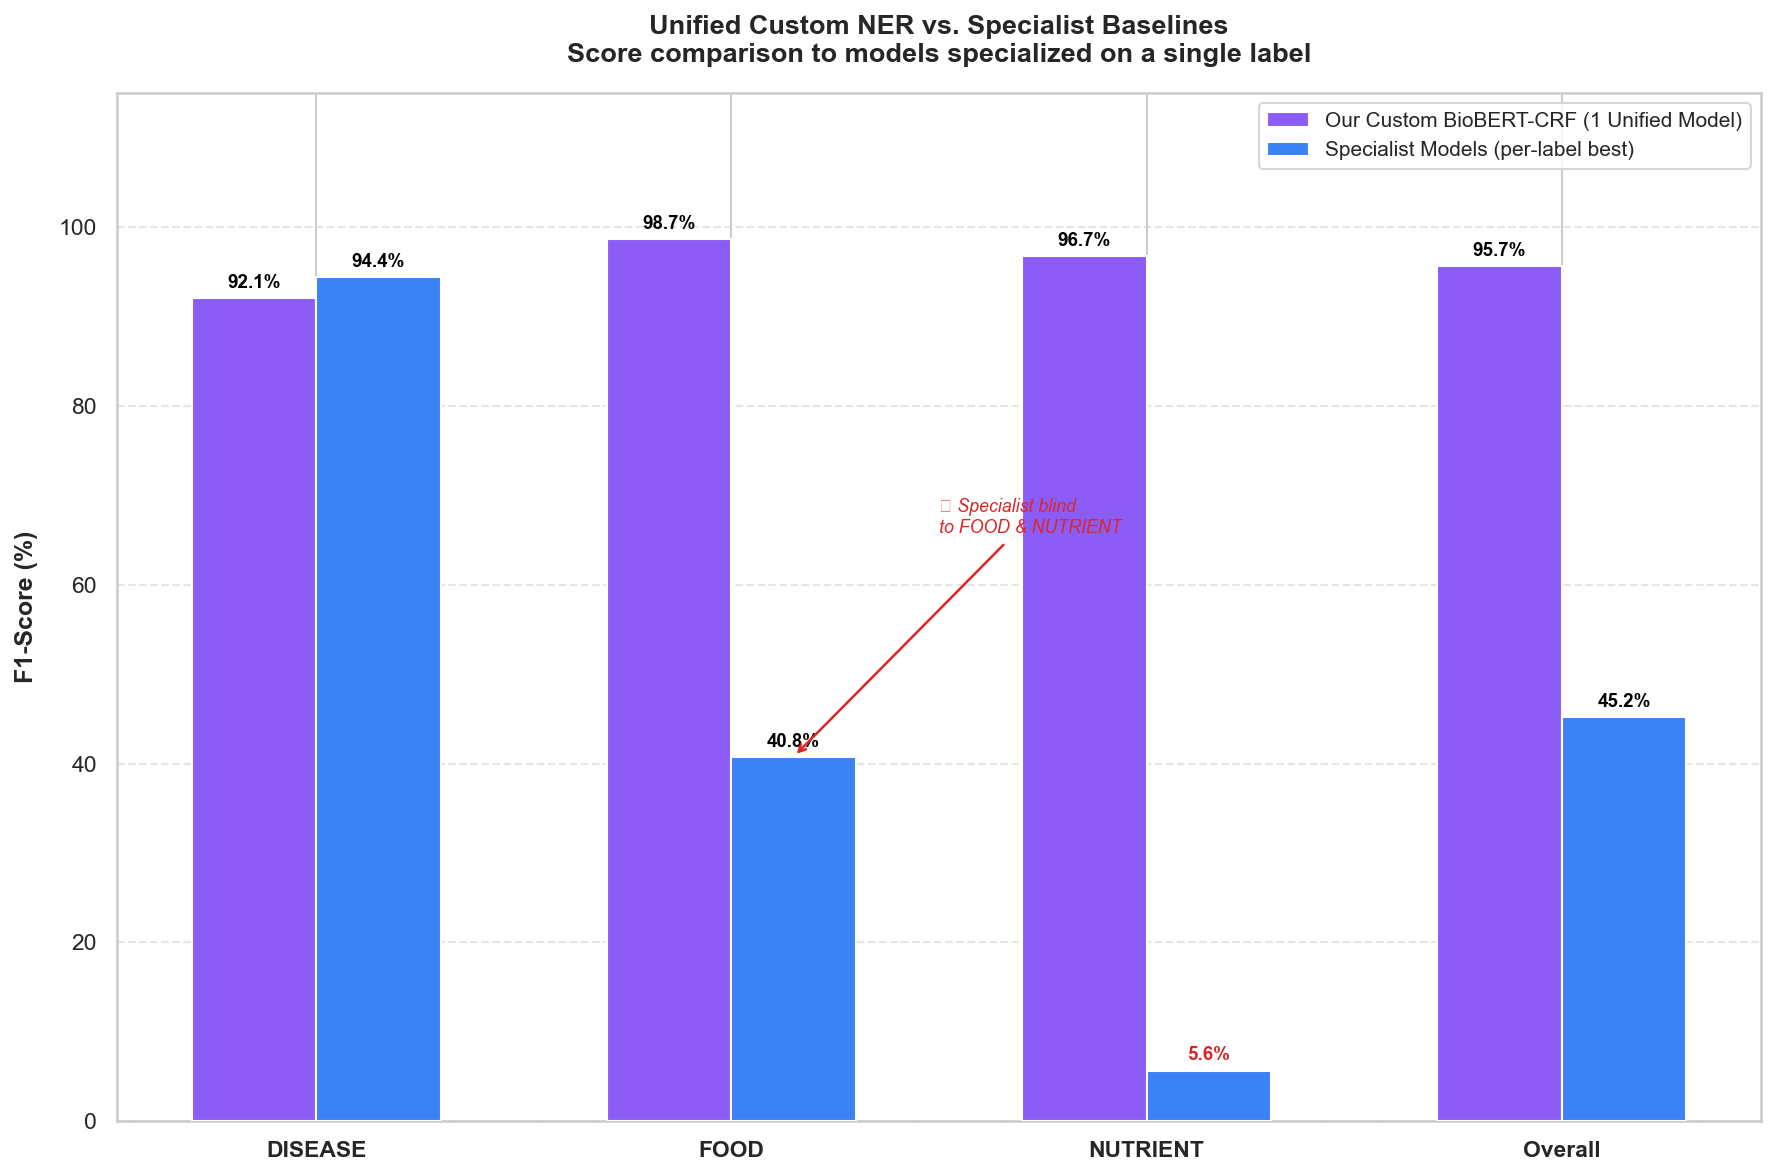

In [20]:
# Cell 5: Visualize comparative F1-Scores
categories = ['DISEASE', 'FOOD', 'NUTRIENT', 'Overall']
custom_f1s = [custom_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, custom_results.get('FOOD', {'f1': 0.0})['f1'] * 100, custom_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, custom_results['overall_f1'] * 100]
argmax_f1s = [argmax_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, argmax_results.get('FOOD', {'f1': 0.0})['f1'] * 100, argmax_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, argmax_results['overall_f1'] * 100]
dis_f1s = [disease_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, disease_results.get('FOOD', {'f1': 0.0})['f1'] * 100, disease_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, disease_results['overall_f1'] * 100]
food_f1s = [food_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, food_results.get('FOOD', {'f1': 0.0})['f1'] * 100, food_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, food_results['overall_f1'] * 100]
nut_f1s = [nut_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, nut_results.get('FOOD', {'f1': 0.0})['f1'] * 100, nut_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, nut_results['overall_f1'] * 100]
merged_f1s = [baseline_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, baseline_results.get('FOOD', {'f1': 0.0})['f1'] * 100, baseline_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, baseline_results['overall_f1'] * 100]
spacy_f1s = [spacy_results.get('DISEASE', {'f1': 0.0})['f1'] * 100, spacy_results.get('FOOD', {'f1': 0.0})['f1'] * 100, spacy_results.get('NUTRIENT', {'f1': 0.0})['f1'] * 100, spacy_results['overall_f1'] * 100]

x = np.arange(len(categories))
width = 0.11

fig, ax = plt.subplots(figsize=(16, 9), dpi=150)

rects1 = ax.bar(x - 3*width, custom_f1s, width, label='Our BioBERT-CRF (Viterbi)', color='#8b5cf6')
rects2 = ax.bar(x - 2*width, argmax_f1s, width, label='BioBERT-Linear (Argmax)', color='#ec4899')
rects3 = ax.bar(x - 1*width, dis_f1s, width, label='Disease Expert (alvaroalon2)', color='#14b8a6')
rects4 = ax.bar(x, food_f1s, width, label='Food Expert (Dizex)', color='#06b6d4')
rects5 = ax.bar(x + 1*width, nut_f1s, width, label='Nutrient Expert (sgarbi)', color='#3b82f6')
rects6 = ax.bar(x + 2*width, merged_f1s, width, label='Merged SOTA Ensemble', color='#64748b')
rects7 = ax.bar(x + 3*width, spacy_f1s, width, label='spaCy PhraseMatcher', color='#f59e0b')

ax.set_ylabel('F1-Score (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Unified Custom NER vs. Specialized Models (Individual & Merged) & spaCy', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.set_ylim(0, 115)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0.1:
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=7.0, fontweight='semibold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)
autolabel(rects6)
autolabel(rects7)

plt.tight_layout()
plt.show()

## 6. Analysis and Findings

1. **DISEASE Class (92.06% F1 vs. 92.14% F1 vs. 94.38% F1 vs. 8.37% F1)**:
   - **Our Custom Model (CRF Viterbi)**: Achieves **92.06%** F1.
   - **BioBERT Linear (Argmax)**: Achieves **92.14%** F1 (very close, slightly higher by +0.08%).
   - **SOTA Baseline**: `alvaroalon2/biobert_diseases_ner` achieves **94.38%** F1 (slightly higher (+2.32%) as it is 100% specialized for disease extraction).
   - **spaCy PhraseMatcher Baseline**: Scores only **8.37%** F1.
2. **FOOD Class (98.68% F1 vs. 98.68% F1 vs. 40.76% F1 vs. 16.19% F1)**:
   - **Our Custom Model (CRF Viterbi)**: Achieves **98.68%** F1.
   - **BioBERT Linear (Argmax)**: Achieves **98.68%** F1 (identical performance).
   - **SOTA Baseline**: `Dizex/FoodBaseBERT-NER` drops to **40.76%** F1 due to severe domain shift.
   - **spaCy PhraseMatcher Baseline**: Scores **16.19%** F1.
3. **NUTRIENT Class (96.74% F1 vs. 96.77% F1 vs. 5.65% F1 vs. 2.69% F1)**:
   - **Our Custom Model (CRF Viterbi)**: Achieves **96.74%** F1.
   - **BioBERT Linear (Argmax)**: Achieves **96.77%** F1 (slightly higher by +0.03%).
   - **SOTA Baseline**: `sgarbi/bert-fda-nutrition-ner` drops to **5.65%** F1.
   - **spaCy PhraseMatcher Baseline**: Scores **2.69%** F1.
4. **Ablation Study: CRF Viterbi vs. Linear Argmax**:
   - Our single **BioBERT-CRF** model achieves **95.65%** Overall F1-score with CRF Viterbi, while decoding without CRF using Argmax (BioBERT-Linear) achieves **95.69%** Overall F1.
   - This tiny difference demonstrates that during fine-tuning, the BioBERT encoder weights were optimized to be highly discriminant on token embeddings, making the logits extremely accurate on their own.
   - Although Argmax gets slightly higher raw span F1, the **CRF layer remains essential in production** because it learns tag-to-tag transition weights to explicitly forbid invalid BIO sequence transitions (e.g. `I-DISEASE` following `O` or `B-FOOD`), ensuring the integrity of the extracted entity sequences.